# 01 - Data Exploration
**Dataset**: Flensburg District Heating Network (2020–2024)
**Goal**: Load the data, understand its structure, and create first visualizations.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid')
%matplotlib inline

In [2]:
FILE = '../data/raw/flensburg_heat_network_2020_2024.xlsx'
df = pd.read_excel(FILE, sheet_name=0, header=1)
print('Columns:', df.columns.tolist())
print('Shape:', df.shape)
df.head()

Columns: ['Unnamed: 0', 'HKW Wärmeleistung\nGesamt', 'Vorlauftemperaturen\nFH Strang 600']
Shape: (43843, 3)


,Unnamed: 0,HKW Wärmeleistung\nGesamt,Vorlauftemperaturen\nFH Strang 600
0,2020-01-01 00:00:00,188.732,95.908
1,2020-01-01 01:00:00,195.986,99.406
2,2020-01-01 02:00:00,188.400,99.831
3,2020-01-01 03:00:00,170.277,96.746
4,2020-01-01 04:00:00,174.004,96.012


In [3]:
TIMESTAMP_COL = df.columns[0]
HEAT_COL = 'HKW Wärmeleistung\nGesamt'
TEMP_COL  = 'Vorlauftemperaturen\nFH Strang 600'

df[TIMESTAMP_COL] = pd.to_datetime(df[TIMESTAMP_COL], errors='coerce')
df = df.dropna(subset=[TIMESTAMP_COL])
df = df.set_index(TIMESTAMP_COL).sort_index()
df.index.name = 'timestamp'

df[HEAT_COL] = pd.to_numeric(df[HEAT_COL], errors='coerce')
df[TEMP_COL]  = pd.to_numeric(df[TEMP_COL],  errors='coerce')

print(f'Date range: {df.index.min()} -> {df.index.max()}')
print(f'Total rows: {len(df)}')
print(f'Missing heat values: {df[HEAT_COL].isnull().sum()}')
df.head()

Date range: 2020-01-01 00:00:00 -> 2024-12-31 23:00:00
Total rows: 43843
Missing heat values: 0


,HKW Wärmeleistung\nGesamt,Vorlauftemperaturen\nFH Strang 600
timestamp,,
2020-01-01 00:00:00,188.732,95.908
2020-01-01 01:00:00,195.986,99.406
2020-01-01 02:00:00,188.400,99.831
2020-01-01 03:00:00,170.277,96.746
2020-01-01 04:00:00,174.004,96.012


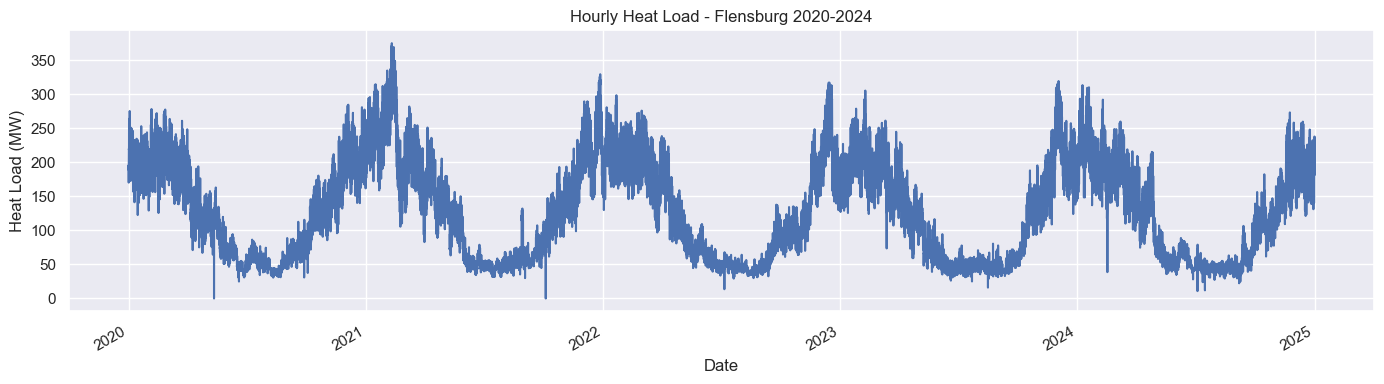

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
df[HEAT_COL].plot(ax=ax)
ax.set_title('Hourly Heat Load - Flensburg 2020-2024')
ax.set_ylabel('Heat Load (MW)')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

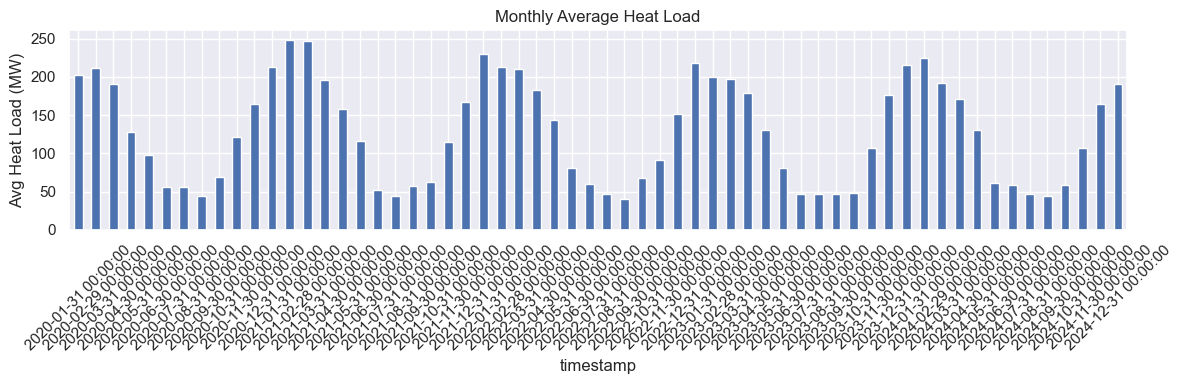

In [5]:
monthly = df[HEAT_COL].resample('ME').mean()
fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(kind='bar', ax=ax)
ax.set_title('Monthly Average Heat Load')
ax.set_ylabel('Avg Heat Load (MW)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

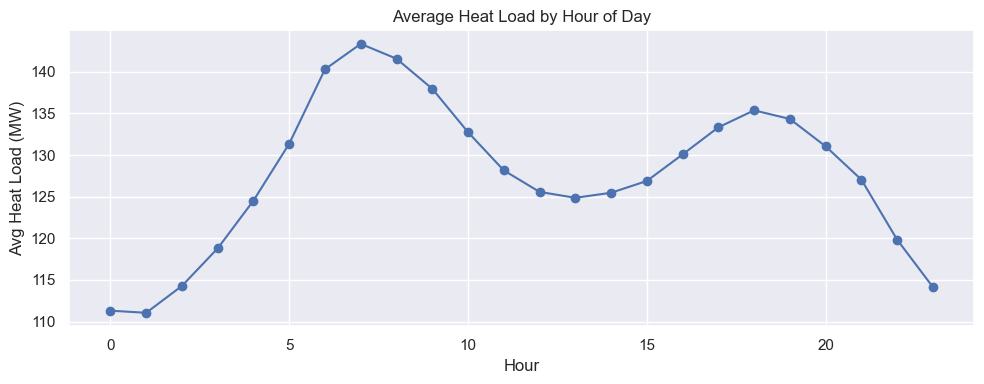

In [6]:
hourly_pattern = df[HEAT_COL].groupby(df.index.hour).mean()
fig, ax = plt.subplots(figsize=(10, 4))
hourly_pattern.plot(ax=ax, marker='o')
ax.set_title('Average Heat Load by Hour of Day')
ax.set_xlabel('Hour')
ax.set_ylabel('Avg Heat Load (MW)')
plt.tight_layout()
plt.show()

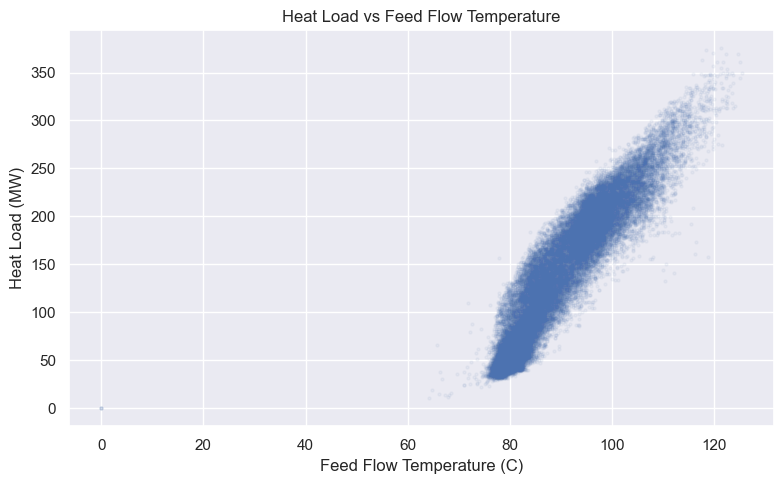

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df[TEMP_COL], df[HEAT_COL], alpha=0.05, s=5)
ax.set_xlabel('Feed Flow Temperature (C)')
ax.set_ylabel('Heat Load (MW)')
ax.set_title('Heat Load vs Feed Flow Temperature')
plt.tight_layout()
plt.show()